# Ohm's Law from Molecular Structure: What "Manufacturing a Compound" Actually Changes

$V=IR$ is a macroscopic circuit relation. This notebook derives $R$ down
to the MOLECULAR level via the Drude model, then compares real compounds
(copper, intrinsic silicon, doped silicon, GaAs) at the SAME fixed wire
geometry -- showing that manufacturing a different compound (or doping it
differently) is what actually sets a resistor's resistance, by 12+ orders
of magnitude. Engine: `dgs/molecular_ohms_law.py`, reusing
`dgs/solid_state_physics.py`'s `drude_conductivity` directly.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import molecular_ohms_law as mol
from dgs.solid_state_physics import drude_conductivity, M_E

sp.init_printing(use_latex="mathjax")
print("Setup complete.")


Setup complete.


## 1. Theory: The Macro-to-Molecular Chain

$$ V = IR, \qquad R = \frac{L}{\sigma A}, \qquad
   \sigma = \frac{n e^2 \tau}{m} $$

$V=IR$ is macroscopic. $R=L/(\sigma A)$ brings in geometry. The Drude
formula $\sigma=ne^2\tau/m$ is where the MATERIAL enters: $n$ (carrier
density) and $\tau$ (mean free time between electron-lattice collisions)
are not free parameters -- they are set by which compound you manufacture
and how it's doped.


In [2]:
n_sym, e_sym, tau_sym, m_sym, L_sym, A_sym = sp.symbols('n e tau m L A', positive=True)
sigma_expr = n_sym*e_sym**2*tau_sym/m_sym
R_expr = L_sym/(sigma_expr*A_sym)
display_chain = [sp.Eq(sp.Symbol('sigma'), sigma_expr), sp.Eq(sp.Symbol('R'), R_expr)]
display_chain


⎡     2                  ⎤
⎢    e ⋅n⋅τ        L⋅m   ⎥
⎢σ = ──────, R = ────────⎥
⎢      m            2    ⎥
⎣                A⋅e ⋅n⋅τ⎦

## 2. SymPy: R Scales Inversely with n -- the Actual Manufacturing Lever

Everything else held fixed, $R\propto 1/n$. Doping introduces donor atoms
into the crystal lattice that each contribute a free carrier -- directly
raising $n$ by orders of magnitude, which is EXACTLY the manufacturing
process parameter (implant dose, diffusion time/temperature) real
semiconductor fabs control.


In [3]:
dRdn = sp.diff(R_expr, n_sym)
print("dR/dn =", dRdn, "  (negative: more carriers -> less resistance, always)")
print("R is inversely proportional to n:", sp.simplify(R_expr * n_sym - L_sym*m_sym/(e_sym**2*tau_sym*A_sym)) == 0)


dR/dn = -L*m/(A*e**2*n**2*tau)   (negative: more carriers -> less resistance, always)
R is inversely proportional to n: True


## 3. Numerical Example: Four Real Compounds, One Fixed Geometry

`dgs/molecular_ohms_law.py`'s `COMPOUND_LIBRARY` carrier densities are
real, standard textbook values (copper's matches
`dgs/solid_state_physics.py`'s own demo exactly); the mean free times are
representative order-of-magnitude values for illustrating the Drude-model
dependence, not measured values for a specific manufactured sample.


In [4]:
L, A = 0.01, 1e-6  # 1 cm length, 1 mm^2 cross-section -- identical for all four
rows = mol.compound_resistance_table(L, A)
print(f"{'compound':40s} {'sigma (S/m)':>14s} {'R (ohm)':>14s}")
print("-"*70)
for row in rows:
    print(f"{row['compound']:40s} {row['sigma_S_per_m']:14.3e} {row['resistance_ohm']:14.3e}")


compound                                    sigma (S/m)        R (ohm)
----------------------------------------------------------------------
copper (Cu, metal)                            5.967e+07      1.676e-04
GaAs (n-type, representative)                 8.412e+03      1.189e+00
n-doped silicon (Si:P, representative)        2.818e+01      3.549e+02
intrinsic silicon (Si)                        4.227e-05      2.366e+08


## 4. Plot: 12+ Orders of Magnitude, Same Geometry


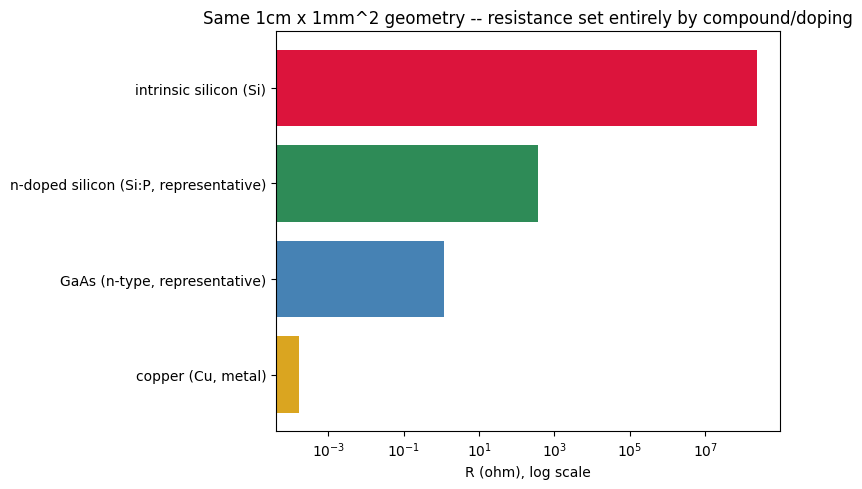

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
names = [r['compound'] for r in rows]
Rs = [r['resistance_ohm'] for r in rows]
colors = ['goldenrod', 'steelblue', 'seagreen', 'crimson']
ax.barh(names, Rs, color=colors)
ax.set_xscale('log')
ax.set_xlabel('R (ohm), log scale')
ax.set_title('Same 1cm x 1mm^2 geometry -- resistance set entirely by compound/doping')
plt.tight_layout()
plt.savefig('molecular_ohms_law_bars.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Parameter Sweep: Resistance vs. Doping Concentration

Sweeping n-type doping density continuously (not just the four discrete
compounds above) shows the actual $R\propto 1/n$ relationship a
semiconductor process engineer is tuning when choosing an implant dose.


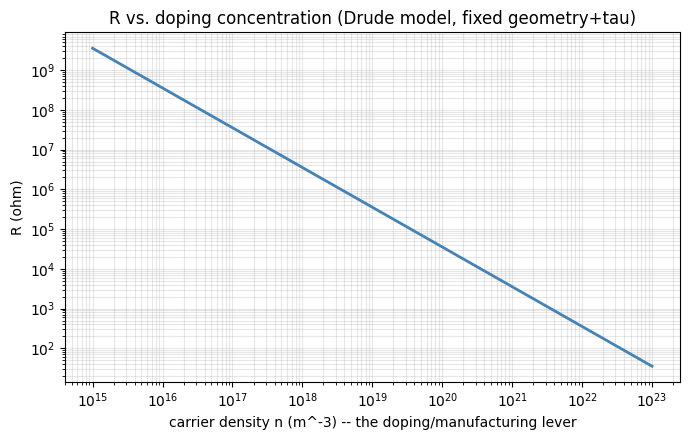

In [6]:
n_sweep = np.logspace(15, 23, 60)  # intrinsic Si to heavily doped, m^-3
sigmas = [drude_conductivity(n, tau=1e-13, m=M_E) for n in n_sweep]
Rs_sweep = [mol.resistance_from_conductivity(s, L, A) for s in sigmas]

fig, ax = plt.subplots(figsize=(7,4.5))
ax.loglog(n_sweep, Rs_sweep, color='steelblue', lw=2)
ax.set_xlabel('carrier density n (m^-3) -- the doping/manufacturing lever')
ax.set_ylabel('R (ohm)')
ax.set_title('R vs. doping concentration (Drude model, fixed geometry+tau)')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('molecular_ohms_law_sweep.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Engineering Interpretation

- This is literally what a semiconductor fab controls: implant dose and
  diffusion profile set $n(x)$ in a doped region, which sets local
  resistance/conductivity -- the same Drude relation used here, applied at
  device-design scale (`dgs/transistor_tech.py`'s MOSFET physics builds on
  exactly this).
- The 12-order-of-magnitude range in section 3-4 is why resistors,
  semiconductors, and conductors are different PRODUCTS, not different
  points on one dial -- copper wire and intrinsic silicon aren't "the same
  material, tuned," they're structurally different regimes of the same
  underlying $\sigma=ne^2\tau/m$ law.


## 7. Research Discussion

- Could `dgs.solid_state_physics.hall_coefficient` be added to this
  notebook to show that Hall-effect measurements are how $n$ (and its
  SIGN -- electron vs. hole carriers) is actually measured in a
  manufactured sample, closing the loop from "we doped it" to "here's the
  proof it worked"?
- The tau values used here are illustrative, not measured -- a real
  extension would cite specific measured mobility values
  ($\mu=e\tau/m$) for each compound/doping level from a materials
  reference, replacing the "representative" hedge with real numbers.


## 8. Possible Experiments

1. Add `dgs.solid_state_physics.hall_voltage` to numerically demonstrate
   how carrier density AND type (n vs p) would be measured in each of
   this notebook's four compounds.
2. Extend `COMPOUND_LIBRARY` with p-type doped silicon (hole carriers,
   opposite Hall-coefficient sign) for a genuinely different carrier type,
   not just a different density.
3. Cite real measured mobility values for each compound (replacing the
   representative tau placeholders) and re-run section 3-5 with them.


## 9. Future Improvements

- If this becomes a real teaching sequence, cross-link it from
  `dgs/transistor_tech.py`'s module docstring (its abstraction-stack
  diagram starts at "silicon atoms -> MOSFET physics" -- this notebook is
  literally the first rung of that ladder, made explicit).
- Temperature dependence (tau and n both vary with T, oppositely for
  metals vs. semiconductors) is a natural next axis, not covered here.
